In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs('charts', exist_ok=True)   #pics(ignore) 

In [8]:
#importdata

brent = yf.download("BZ=F", start="2020-01-01", end=None)
brent.columns = brent.columns.get_level_values(0)

wti = yf.download("CL=F", start="2020-01-01", end=None)
wti.columns = wti.columns.get_level_values(0)

brent.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,66.250000,66.570000,65.730003,66.470001,25810
2020-01-03,68.599998,69.480003,66.220001,66.290001,78848
2020-01-06,68.910004,70.720001,68.190002,69.070000,51933
2020-01-07,68.269997,68.739998,67.650002,68.580002,41178
2020-01-08,65.440002,71.989998,64.940002,68.470001,85232


In [9]:
brent.info()
brent.describe()
brent.isna().sum()

#checkdataframe

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1649 entries, 2020-01-02 to 2026-07-22
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1649 non-null   float64
 1   High    1649 non-null   float64
 2   Low     1649 non-null   float64
 3   Open    1649 non-null   float64
 4   Volume  1649 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.3 KB


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

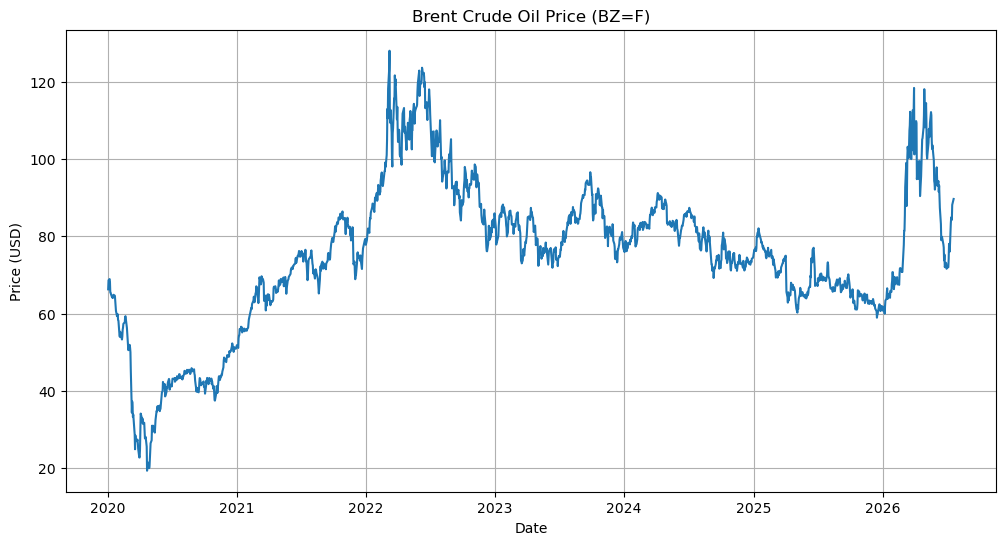

In [4]:
plt.figure(figsize=(12,6))
plt.plot(brent.index, brent['Close'])
plt.title('Brent Crude Oil Price (BZ=F)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.savefig('charts/price_chart.png', dpi=150, bbox_inches='tight')
plt.show()

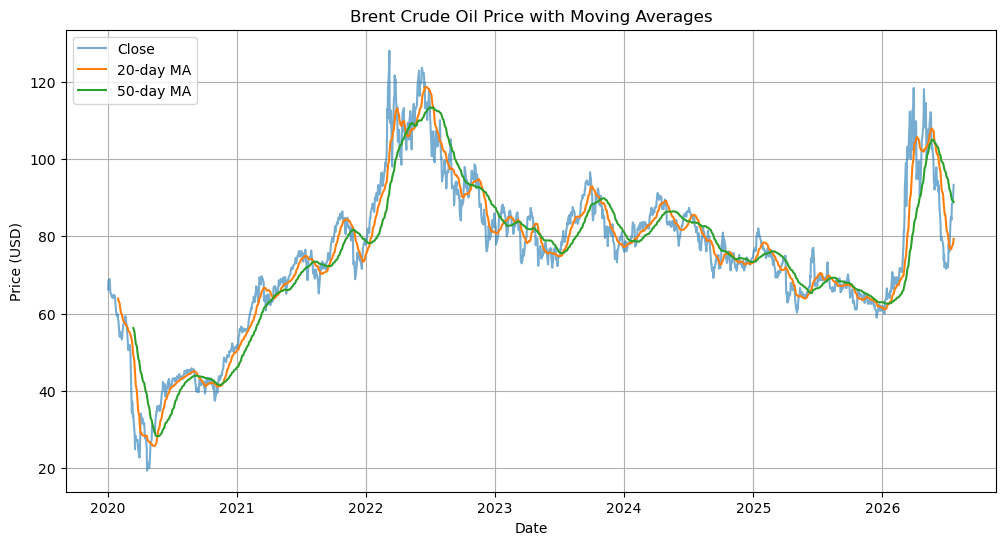

In [10]:
brent['MA20'] = brent['Close'].rolling(window=20).mean()    #movingAvg1
brent['MA50'] = brent['Close'].rolling(window=50).mean()  #movingAvg2

plt.figure(figsize=(12,6))
plt.plot(brent.index, brent['Close'], label='Close', alpha=0.6)
plt.plot(brent.index, brent['MA20'], label='20-day MA')
plt.plot(brent.index, brent['MA50'], label='50-day MA')
plt.title('Brent Crude Oil Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('charts/moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

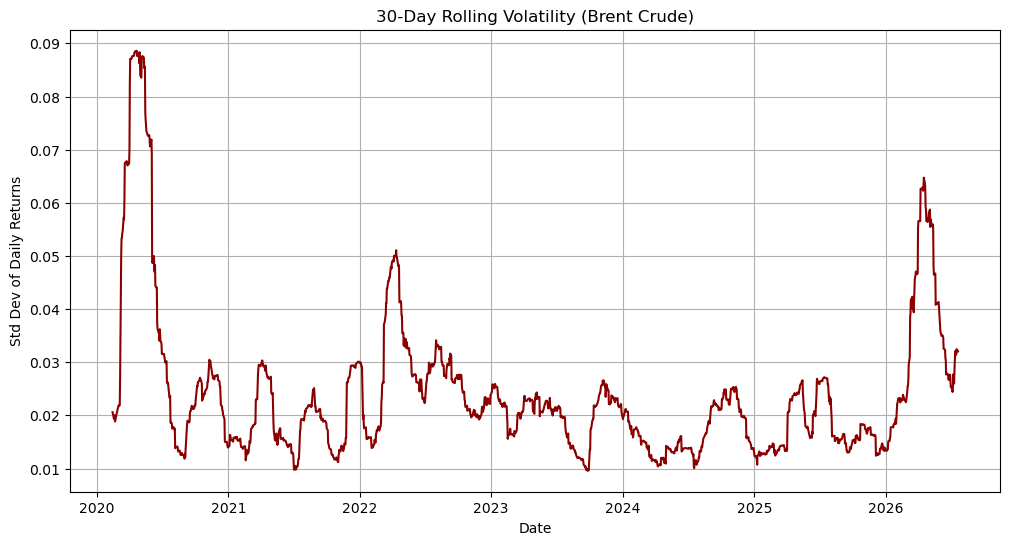

In [6]:
brent['Daily_Return'] = brent['Close'].pct_change()
brent['Volatility_30'] = brent['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(brent.index, brent['Volatility_30'], color='darkred')
plt.title('30-Day Rolling Volatility (Brent Crude)')
plt.xlabel('Date')
plt.ylabel('Std Dev of Daily Returns')
plt.grid(True)
plt.savefig('charts/volatility.png', dpi=150, bbox_inches='tight')
plt.show()

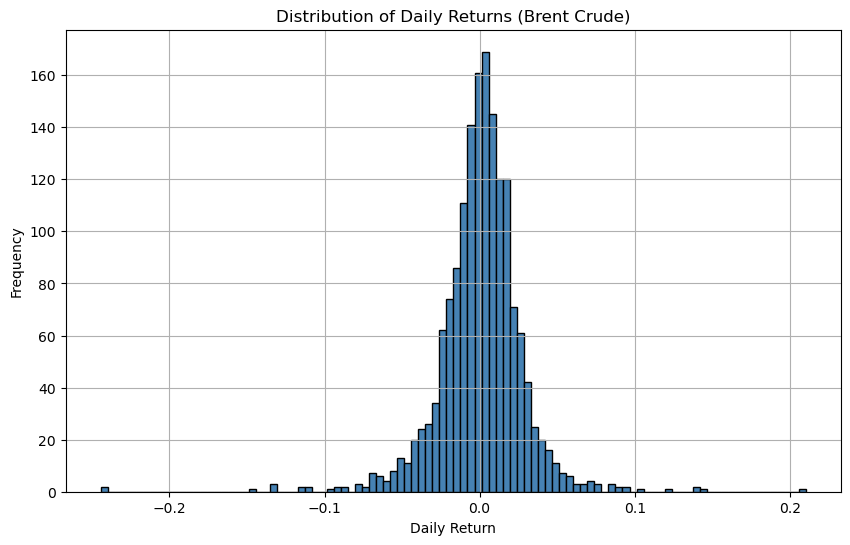

In [7]:
plt.figure(figsize=(10,6))
plt.hist(brent['Daily_Return'].dropna(), bins=100, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Returns (Brent Crude)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('charts/returns_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

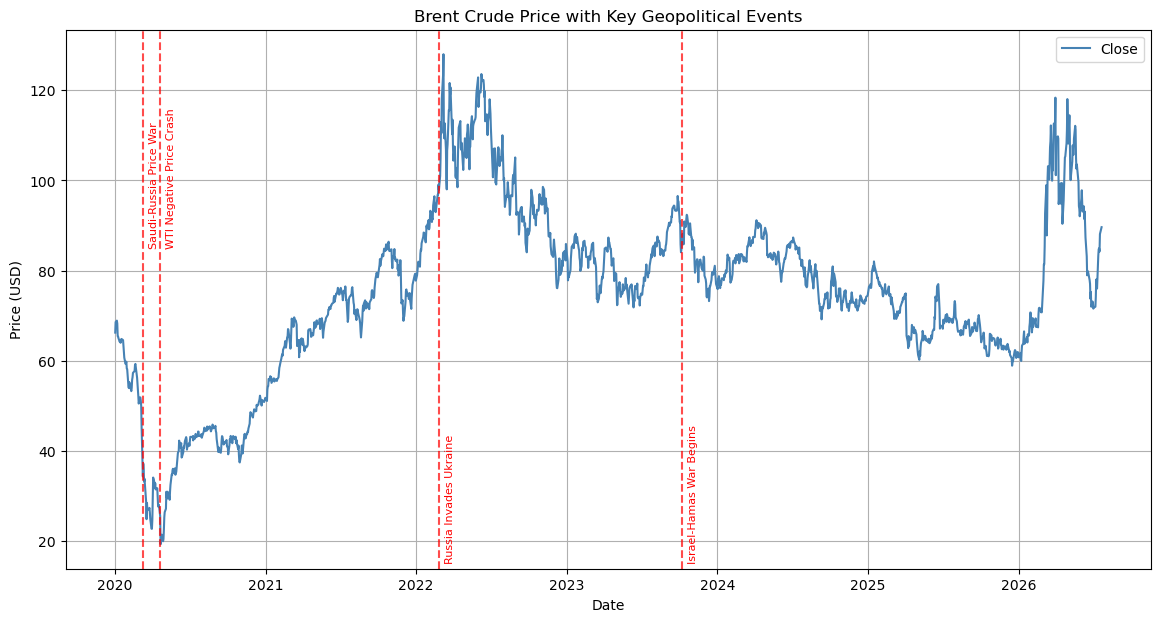

In [8]:
events = {
    '2020-03-09': 'Saudi-Russia Price War',
    '2020-04-20': 'WTI Negative Price Crash',
    '2022-02-24': 'Russia Invades Ukraine',
    '2023-10-07': 'Israel-Hamas War Begins',
}

plt.figure(figsize=(14,7))
plt.plot(brent.index, brent['Close'], label='Close', color='steelblue')

for date, label in events.items():
    date = pd.to_datetime(date)
    plt.axvline(date, color='red', linestyle='--', alpha=0.7)
    y_pos = 85 if '2020' in date.strftime('%Y') else 15
    plt.text(date + pd.Timedelta(days=15), y_pos, label, rotation=90, verticalalignment='bottom', fontsize=8, color='red')

plt.title('Brent Crude Price with Key Geopolitical Events')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('charts/event_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

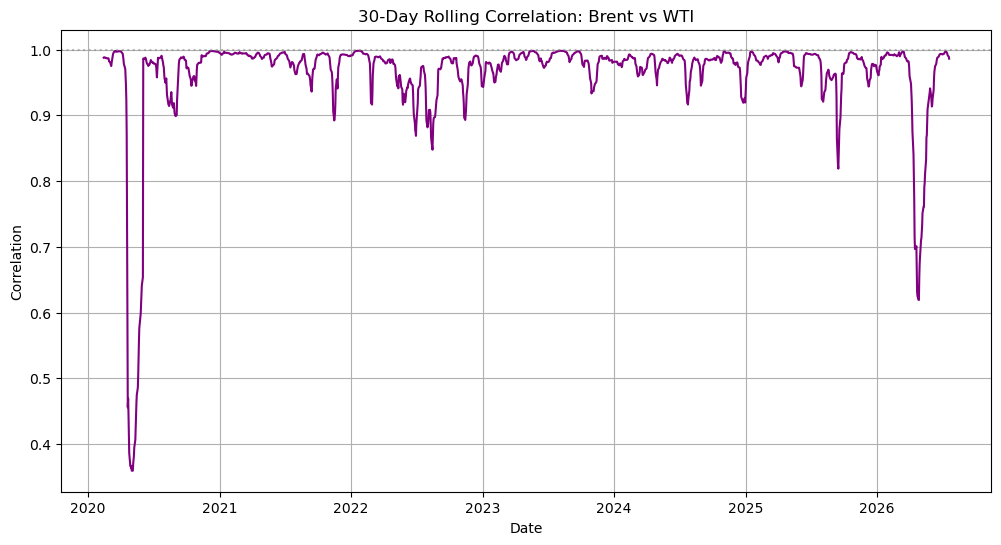

In [9]:
combined = pd.DataFrame({
    'Brent': brent['Close'],
    'WTI': wti['Close']
}).dropna()

combined['Rolling_Corr'] = combined['Brent'].rolling(window=30).corr(combined['WTI'])

plt.figure(figsize=(12,6))
plt.plot(combined.index, combined['Rolling_Corr'], color='purple')
plt.title('30-Day Rolling Correlation: Brent vs WTI')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.axhline(1, color='gray', linestyle=':', alpha=0.5)
plt.grid(True)
plt.savefig('charts/wti_correlation.png', dpi=150, bbox_inches='tight')
plt.show()